In [1]:
import numpy as np
import fastplotlib as fpl
from fastplotlib.widgets.nd_widget._nd_positions import NDPositions

Unable to find extension: VK_EXT_physical_device_drm


Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),AMD Radeon RX 570 Series (RADV POLARIS10),DiscreteGPU,Vulkan,Mesa 22.3.6
✅,NVIDIA GeForce RTX 3080,DiscreteGPU,Vulkan,575.57.08
❗ limited,"llvmpipe (LLVM 15.0.6, 256 bits)",CPU,Vulkan,Mesa 22.3.6 (LLVM 15.0.6)
❌,"AMD Radeon RX 570 Series (polaris10, LLVM 15.0.6, DRM 3.49, 6.1.0-41-amd64)",Unknown,OpenGL,4.6 (Core Profile) Mesa 22.3.6


pygfx version from git (0.9.0) and __version__ (0.15.0) don't match.
To silence this warning, use a fully namespaced name.


In [ ]:
n = 100
p = 10_000_000
xs = np.linspace(0, 100_000 * np.pi, p, dtype=np.float32)# + np.random.normal(0, 0.2, size=p)

def xs_mapping(x) -> int:
    """maps world space x position -> array index"""
    return int((x * 100) // np.pi)

xs_mapping(xs[132154])

data = np.zeros((n, p, 2), dtype=np.float32)
for i in range(n):
    data[i] = np.column_stack([xs, np.sin(xs * 5) + 0 + np.random.normal(scale=0.5, size=p)])

data.shape

In [31]:
data = np.load("./big_array.npy")

In [32]:
from ipywidgets import IntSlider, VBox, Layout

In [33]:
ndp = NDPositions(data, graphic=fpl.LineStack, display_window=1000, multi=True)
# ndp2 = NDPositions(data, graphic=fpl.ScatterCollection, display_window=100, multi=True)

In [34]:
def update_dw(change):
    ndp.display_window = change["new"]
    fig[0, 0].auto_scale()

slider_dw = IntSlider(min=10, max=ndp.processor.data.shape[-2], value=1_000, description="disp window", layout=Layout(width="600px"))
slider_dw.observe(update_dw, "value")

def update_t(change):
    processors = [ndp]
    for pr in processors:
        pr.indices = (change["new"],)
    fig[0, 0].auto_scale()

slider = IntSlider(min=0, max=p, value=0, description="index", layout=Layout(width="600px"))
slider.observe(update_t, "value")

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
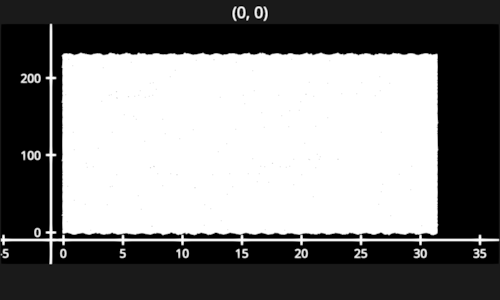

In [35]:
fig = fpl.Figure()

fig[0, 0].add_graphic(ndp.graphic)
# fig[0, 0].add_graphic(ndp2.graphic)

fig.show(maintain_aspect=False)

In [ ]:
xrange = (0, 10)

def update_view():
    xmin, ymin, xmax, ymax = fig[0, 0].frame.rect
    yavg = (ymax - ymin) / 2
    
    xrange_world = [fig[0, 0].map_screen_to_world((x, y))[0] for x, y in [(xmin + 1, yavg), (xmax - 1, yavg)]]
    global xrange
    if xrange_world == xrange:
        return
    xrange = xrange_world

    x0, x1 = xs_mapping(xrange[0]), xs_mapping(xrange[1])
    
    disp_window = x1 - x0
    ndp.display_window = disp_window
    ndp.indices = (int(np.mean([x0, x1])),)

fig.add_animations(update_view)

In [8]:
VBox([slider_dw, slider])

In [9]:
ndp.processor.max_display_datapoints

1000

In [10]:
p // (p // ndp.processor.max_display_datapoints)

1000

In [10]:
%load_ext viztracer

In [11]:
%%viztracer
ndp.indices = (5825473,)
fig[0, 0].auto_scale()

Button(description='VizTracer Report', style=ButtonStyle())

In [14]:
%%timeit
ndp.processor.data[:, ::(p // ndp.processor.max_display_datapoints)]

237 ns ± 4.37 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [15]:
ndp.graphic = fpl.LineStack
fig[0, 0].auto_scale()

In [40]:
ndp.graphic[0].data.value.shape

(1001, 3)

In [8]:
ndp.display_window = 10_000

In [9]:
ndp.graphic[0].data.value.shape

(1000, 3)

In [11]:
ndp.processor._datapoints_window_func = (np.mean, "y")

In [12]:
ndp.processor._datapoints_window_size = 11

In [16]:
ndp.graphic = fpl.LineStack